# Analysis of Spectral Data Sources

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import distance_matrix
import numpy as np
from scipy.stats import skew
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.dates as mdates
import os
import sys
from pathlib import Path
import matplotlib.animation as animation


sys.path.append(str(Path.cwd().parent))


In [34]:
# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent

NAME_FILE = "RNH_20251116_132312_ALPS"+".csv"

FONTSIZE_MAIN = 14
FONTSIZE_SEC = 12

MIN_WINDOW = 0 #350 for checking possible leak 
MAX_WINDOW = 4300 #400 for checking possible leak

In [35]:
result = pd.read_csv(current_dir / "datasets" / "raw" /"ScenariosV5_test"/ NAME_FILE, sep=',', encoding='ISO-8859-1')


In [36]:
result.columns

Index(['CURRENTTIMESTAMP', '189.73', '190.12', '190.5', '190.88', '191.27',
       '191.65', '192.04', '192.42', '192.8',
       ...
       'ISSPECTROMETERFAULT', 'ISHVMODULEFAULT', 'ISPOLLUTIONFAULT',
       'ISALPSCONFIGERROR', 'ALPSSerial', 'DOWN', 'DOWNMSG',
       'SENSORPRESSURECHAMBER1', 'ETATREALTIMELIFE', 'ANOMALY?'],
      dtype='object', length=2104)

In [37]:
result.columns[2049:]

Index(['RS1', 'RS2', 'RS3', 'RS4', 'RS5', 'RS6', 'RS7', 'RS8', 'RS9', 'RS10',
       'RS11', 'RS12', 'RS13', 'RS14', 'RS15', 'RS16', 'RS17', 'RS18', 'RS19',
       'RS20', 'RS21', 'RS22', 'RS23', 'RS24', 'RS25', 'RS26', 'RS27', 'RS28',
       'RS29', 'RS30', 'RS31', 'RS32', 'VOLTAGE', 'CURRENT', 'PRESSURE',
       'WARMUP', 'ACTIVE', 'REGULATIONON', 'PLASMAON', 'PLASMAOFFFORCED',
       'PLASMASTATUS', 'WARNING', 'ISPOWERSAVINGMODE', 'ISTEMPERATUREFAULT',
       'ISCURRENTFAULT', 'ISSPECTROMETERFAULT', 'ISHVMODULEFAULT',
       'ISPOLLUTIONFAULT', 'ISALPSCONFIGERROR', 'ALPSSerial', 'DOWN',
       'DOWNMSG', 'SENSORPRESSURECHAMBER1', 'ETATREALTIMELIFE', 'ANOMALY?'],
      dtype='object')

In [38]:
result.columns[-1]

'ANOMALY?'

In [39]:
result['CURRENTTIMESTAMP'] = pd.to_datetime(result['CURRENTTIMESTAMP'])#.dt.tz_convert('UTC')



In [40]:
min_date = result.CURRENTTIMESTAMP.min()
print("Min Date:", min_date)


Min Date: 2025-11-16 13:23:17.053000+00:00


In [41]:
max_date = result.CURRENTTIMESTAMP.max()
print("Max Date:", max_date)

Max Date: 2025-11-16 14:33:16.091000+00:00


In [42]:

Components_final = result.iloc[MIN_WINDOW:MAX_WINDOW].copy()

print("Min Date:", min_date)

Min Date: 2025-11-16 13:23:17.053000+00:00


In [43]:

print("Max Date:", max_date)

Max Date: 2025-11-16 14:33:16.091000+00:00


In [44]:
print("Length:",len(Components_final))

Length: 4200


In [45]:
# 1. Create the Group ID (same as before)
result['group_id'] = (result['ANOMALY?'] != result['ANOMALY?'].shift()).cumsum()

# 2. Filter for anomalies
anomalies = result[result['ANOMALY?'] == 1]

# 3. Find the MAX date for each group (The time the anomaly stopped)
min_date_abnormal_case = anomalies.groupby('group_id')['CURRENTTIMESTAMP'].min().iloc[0]
max_date_abnormal_case = anomalies.groupby('group_id')['CURRENTTIMESTAMP'].max().iloc[0]

In [46]:
delta_window = 60 # by default 60

In [47]:
total_min_abnormal_case = min_date_abnormal_case - pd.Timedelta(delta_window, unit='s')
total_max_abnormal_case = max_date_abnormal_case + pd.Timedelta(delta_window, unit='s')

In [48]:

min_date_filter = result['CURRENTTIMESTAMP']>=total_min_abnormal_case
example_abnormal = result[min_date_filter]
print("Min Date (Filtered Abnormal):", example_abnormal.CURRENTTIMESTAMP.min())

Min Date (Filtered Abnormal): 2025-11-16 13:25:18.227000+00:00


In [49]:
max_date_filter = example_abnormal['CURRENTTIMESTAMP']<=total_max_abnormal_case
example_abnormal = example_abnormal[max_date_filter]
print("Max Date (Filtered Abnormal):", example_abnormal.CURRENTTIMESTAMP.max())

Max Date (Filtered Abnormal): 2025-11-16 13:28:14.480000+00:00


## Analysing Datasets

In [50]:

result = Components_final

In [51]:
MAX_POS_SPECTRA = 2049
MIN_POS_SPECTRA = 1

In [52]:
cols_slice = result.columns[MIN_POS_SPECTRA:MAX_POS_SPECTRA]

# Convert the slice to float *once* for efficiency
cols_as_float = cols_slice.astype(float)

In [53]:
# Nitrogen (RS1)
# Create the mask using & (bitwise AND) and parentheses
mask = (cols_as_float > 380.22) & (cols_as_float <= 400.20)
# Now apply the mask
filtered_column_names = cols_slice[mask]
n_wavelength = filtered_column_names[int(len(filtered_column_names)/2)]
n_color = "indigo" 
print(n_wavelength)

390.17


In [54]:
# Oxigen (RS2)
# Create the mask using & (bitwise AND) and parentheses
mask = (cols_as_float > 767.01) & (cols_as_float <= 787.02)
# Now apply the mask
filtered_column_names = cols_slice[mask]
o_wavelength = filtered_column_names[int(len(filtered_column_names)/2)]
o_color = "maroon"
print(o_wavelength)

777.05


In [55]:
# Argon (RS3)
# Create the mask using & (bitwise AND) and parentheses
mask = (cols_as_float > 748.06) & (cols_as_float <= 752.50)
# Now apply the mask
filtered_column_names = cols_slice[mask]
a_wavelength = filtered_column_names[int(len(filtered_column_names)/2)]
a_color = "firebrick"
print(a_wavelength)

750.5


In [56]:
# OH (RS4)
# Create the mask using & (bitwise AND) and parentheses
mask = (cols_as_float > 302.18) & (cols_as_float <= 310.30)
# Now apply the mask
filtered_column_names = cols_slice[mask]
oh_wavelength = filtered_column_names[int(len(filtered_column_names)/2)]
oh_color = "darkorange"
print(oh_wavelength)

306.54


### Spectral data in Time

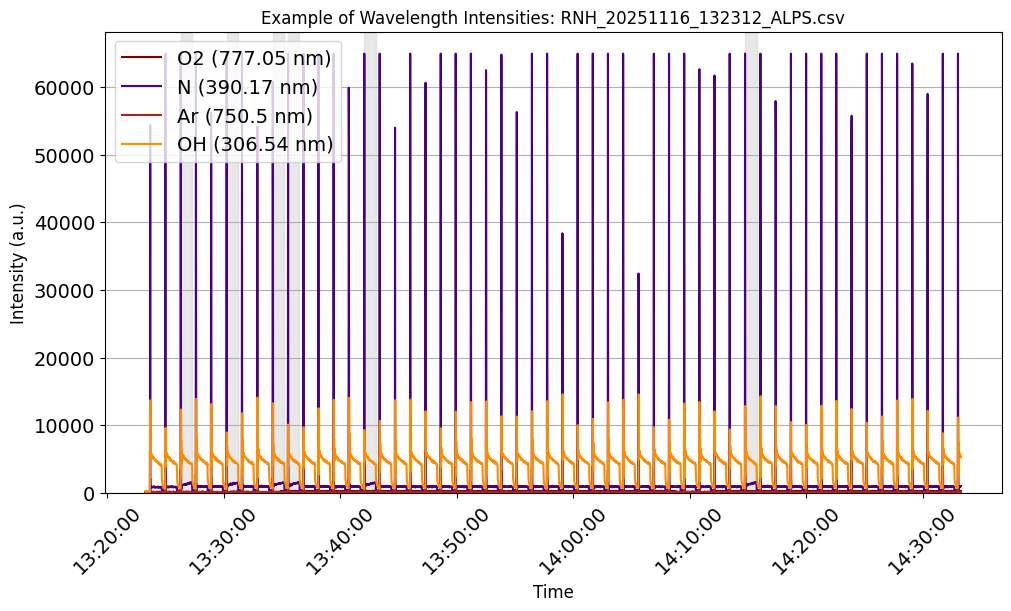

In [57]:
fig, ax1 = plt.subplots(figsize=(10, 6), layout="constrained")

try:
    ax1.plot(result.CURRENTTIMESTAMP, result[o_wavelength], color=o_color, label=f"O2 ({o_wavelength} nm)")
    ax1.plot(result.CURRENTTIMESTAMP, result[n_wavelength], color=n_color, label=f"N ({n_wavelength} nm)")
    ax1.plot(result.CURRENTTIMESTAMP, result[a_wavelength], color=a_color, label=f"Ar ({a_wavelength} nm)")
    ax1.plot(result.CURRENTTIMESTAMP, result[oh_wavelength], color=oh_color, label=f"OH ({oh_wavelength} nm)")

    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Intensity (a.u.)', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Wavelength Intensities: '+ NAME_FILE, fontsize=FONTSIZE_SEC)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax1.grid(axis='y')
    
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)
    ax1.set_ylim(0, )


    try:
        ax1.fill_between(
            result.CURRENTTIMESTAMP, 
            0, 
            1, 
            where=(result["ANOMALY?"].values == 1), 
            color='lightgrey', 
            alpha=0.5, 
            transform=ax1.get_xaxis_transform()
        )
    except:
        print("No Ground Truth available for grey area")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    ax1.legend(lines_1, labels_1, loc='upper left', fontsize=FONTSIZE_MAIN)

    plt.show()

except Exception as e:
    print("Error plotting specific wavelengths", e)

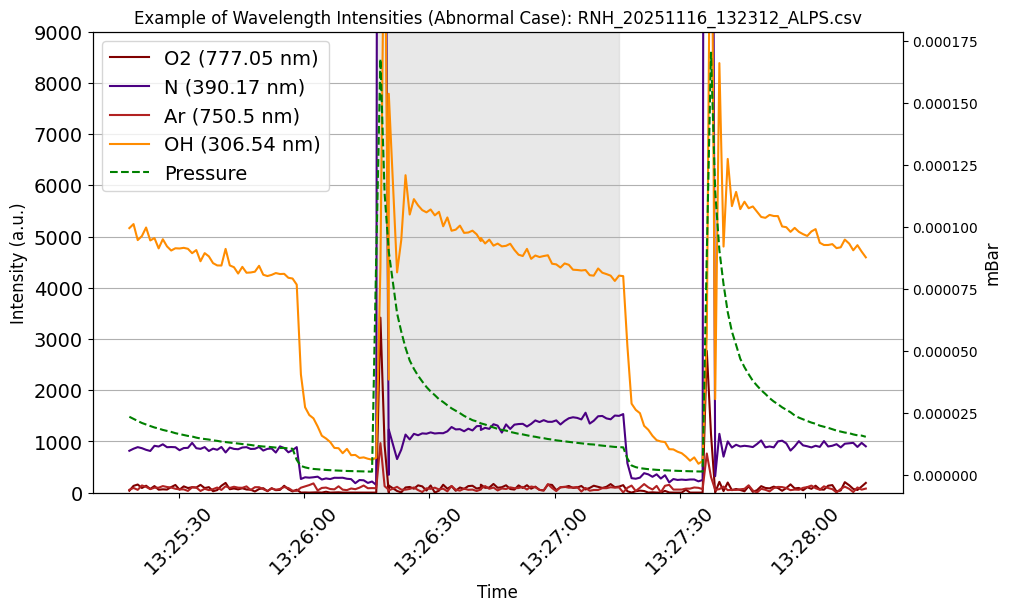

In [58]:
try:
    fig, ax1 = plt.subplots(figsize=(10, 6), layout="constrained")

    ax1.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal[o_wavelength], color=o_color, label=f"O2 ({o_wavelength} nm)")
    ax1.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal[n_wavelength], color=n_color, label=f"N ({n_wavelength} nm)")
    ax1.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal[a_wavelength], color=a_color, label=f"Ar ({a_wavelength} nm)")
    ax1.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal[oh_wavelength], color=oh_color, label=f"OH ({oh_wavelength} nm)")

    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Intensity (a.u.)', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Wavelength Intensities (Abnormal Case): ' + NAME_FILE, fontsize=FONTSIZE_SEC)
    
    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax1.grid(axis='y')
    ax1.set_ylim(0, 9000)
    
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    try:
        ax1.fill_between(
            example_abnormal.CURRENTTIMESTAMP, 
            0, 
            1, 
            where=(example_abnormal["ANOMALY?"].values == 1), 
            color='lightgrey', 
            alpha=0.5, 
            transform=ax1.get_xaxis_transform()
        )
    except:
        print("No Ground Truth available for grey area")

    ax2 = ax1.twinx()
    try:
        ax2.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal["PRESSURE"], linestyle="dashed", color="green", label="Pressure")
        ax2.set_ylabel('mBar', fontsize=FONTSIZE_SEC)
    except:
        print("No info. available")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=FONTSIZE_MAIN)

    plt.show()

except Exception as e:
    print("Error plotting specific wavelengths", e)

### Extra Features in Time

#### Pressure for Different Chambers

/tmp/ipykernel_550334/4138966802.py:29: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(False, linestyle='--', alpha=0.06)


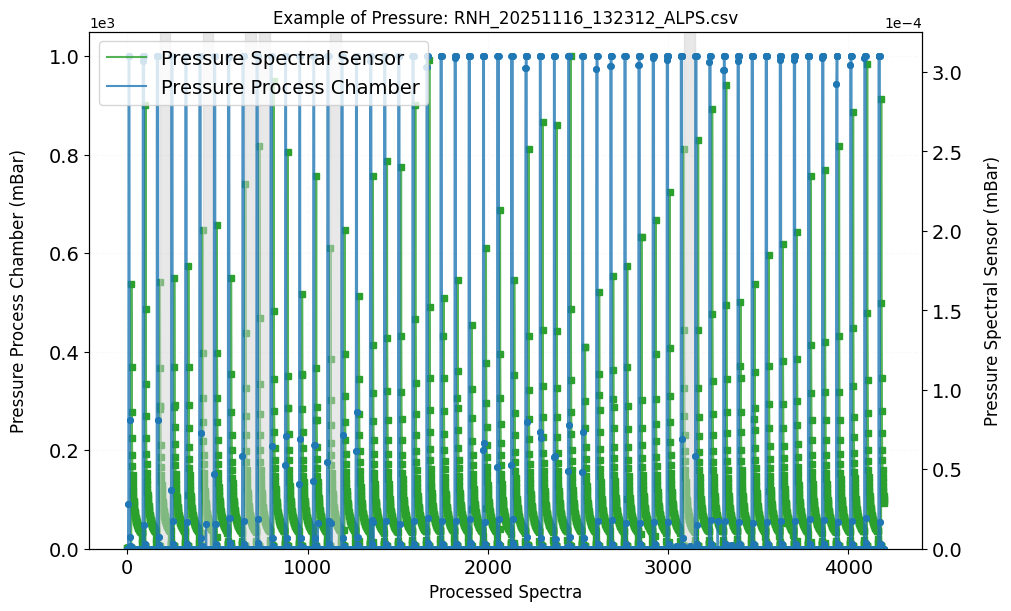

In [59]:
fig, ax1 = plt.subplots(figsize=(10, 6), layout="constrained")

try:
    spectra_count = range(len(result.CURRENTTIMESTAMP))
    
    ax2 = ax1.twinx()
    ax2.set_zorder(1)
    ax1.set_zorder(2)
    ax1.patch.set_visible(False)

    ax2.plot(spectra_count, result["PRESSURE"], color="#2ca02c", label="Pressure Spectral Sensor", alpha=0.8)
    ax2.plot(spectra_count, result["PRESSURE"], color="#2ca02c", marker='s', markersize=4, linestyle='None')
    ax2.set_ylabel('Pressure Spectral Sensor (mBar)', fontsize=FONTSIZE_SEC, labelpad=15)
    
    ax2.set_ylim(bottom=0)
    ax2.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

    ax1.plot(spectra_count, result["SENSORPRESSURECHAMBER1"], color="#1f77b4", label="Pressure Process Chamber", alpha=0.8)
    ax1.plot(spectra_count, result["SENSORPRESSURECHAMBER1"], color="#1f77b4", marker='o', markersize=4, linestyle='None')
    ax1.set_xlabel('Processed Spectra', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Pressure Process Chamber (mBar)', fontsize=FONTSIZE_SEC, labelpad=15)
    
    ax1.set_ylim(bottom=0)
    ax1.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    
    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax1.grid(False, linestyle='--', alpha=0.06)

    try:
        ax1.fill_between(
            spectra_count, 
            0, 
            1, 
            where=(result["ANOMALY?"] == 1), 
            color='lightgrey', 
            alpha=0.5, 
            transform=ax1.get_xaxis_transform()
        )
    except:
        pass

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_2 + lines_1, labels_2 + labels_1, loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.set_title('Example of Pressure: ' + NAME_FILE, fontsize=FONTSIZE_SEC)
    plt.show()

except:
    print("No Pressure Chamber available")

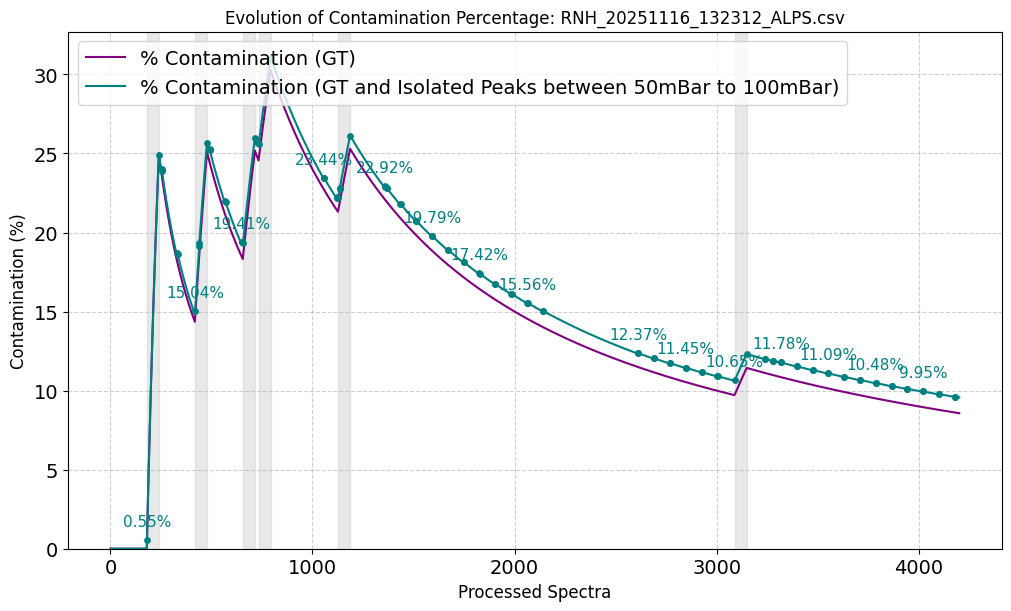

In [60]:
fig, ax1 = plt.subplots(figsize=(10, 6), layout="constrained")

try:
    cumulative_abnormal = result["ANOMALY?"].cumsum()
    cumulative_total = result["ANOMALY?"].expanding().count()
    contamination_ratio = (cumulative_abnormal / cumulative_total) * 100

    pressure = result["SENSORPRESSURECHAMBER1"]
    
    is_in_range = (pressure <= 100) & (pressure > 50)
    is_peak = (pressure > pressure.shift(-1))
    
    custom_anomaly = is_in_range & is_peak
    
    cumulative_custom = custom_anomaly.cumsum()
    custom_contamination_ratio = ((cumulative_custom + cumulative_abnormal) / cumulative_total) * 100

    ax1.plot(cumulative_total, contamination_ratio, color="purple", label="% Contamination (GT)")
    ax1.plot(cumulative_total, contamination_ratio, color="purple", linestyle='None')

    ax1.plot(cumulative_total, custom_contamination_ratio, color="teal", label="% Contamination (GT and Isolated Peaks between 50mBar to 100mBar)")
    ax1.plot(cumulative_total, custom_contamination_ratio, color="teal", linestyle='None')
    
    mask_gt = result["ANOMALY?"].diff().fillna(0) != 0
    mask_custom = custom_anomaly.astype(int).diff().fillna(0) != 0
    mask_combined = mask_gt | mask_custom

    x_points = cumulative_total[mask_combined].values
    y_points = custom_contamination_ratio[mask_combined].values

    ax1.scatter(x_points, y_points, color="teal", s=15, zorder=5)
    
    plotted_x = []
    min_x_distance = (cumulative_total.max() - cumulative_total.min()) * 0.05

    for x, y in zip(x_points, y_points):
        if not any(abs(x - px) < min_x_distance for px in plotted_x):
            ax1.annotate(f"{y:.2f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=11, color="teal")
            plotted_x.append(x)

    ax1.set_xlabel('Processed Spectra', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Contamination (%)', fontsize=FONTSIZE_SEC)
    ax1.set_title('Evolution of Contamination Percentage: ' + NAME_FILE, fontsize=FONTSIZE_SEC)
    
    ax1.set_ylim(bottom=0)
    
    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    ax1.fill_between(
        cumulative_total, 
        0, 
        1, 
        where=(result["ANOMALY?"] == 1), 
        color='lightgrey', 
        alpha=0.5, 
        transform=ax1.get_xaxis_transform()
    )
    
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)
    plt.show()

except Exception as e:
    print(e)

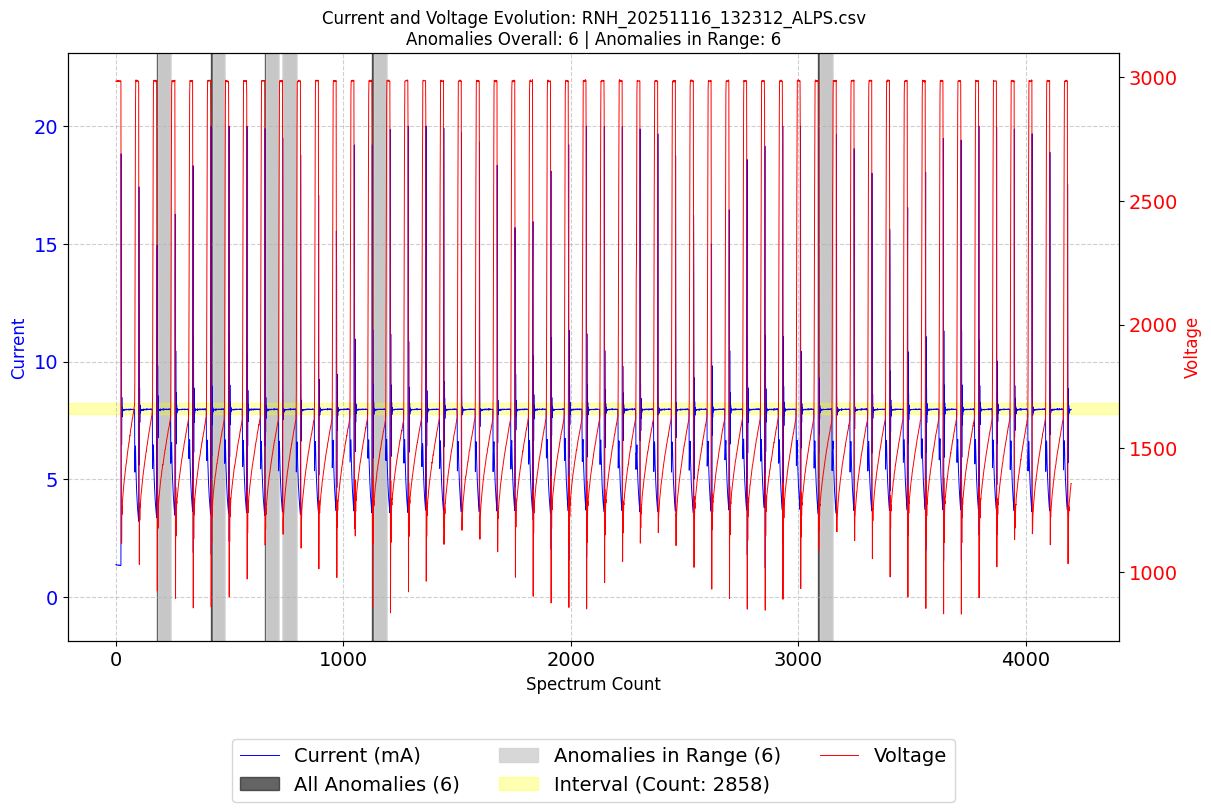

In [61]:
fig, ax1 = plt.subplots(figsize=(12, 8), layout="constrained")

lower_bound = 7.75
upper_bound = 8.25

try:
    spectrum_index = range(len(result))
    
    mask_in_range = (result["CURRENT"] >= lower_bound) & (result["CURRENT"] <= upper_bound)
    values_in_range = mask_in_range.sum()
    
    target_series_overall = result["ANOMALY?"].fillna(0).astype(int)
    condition_changes_overall = (target_series_overall != target_series_overall.shift()).cumsum()
    group_sums_overall = target_series_overall.groupby(condition_changes_overall).sum()
    num_anomalies_overall = len(group_sums_overall[group_sums_overall > 0])
    
    target_series_narrowed = (target_series_overall & mask_in_range).astype(int)
    condition_changes_narrowed = (target_series_narrowed != target_series_narrowed.shift()).cumsum()
    group_sums_narrowed = target_series_narrowed.groupby(condition_changes_narrowed).sum()
    num_anomalies_narrowed = len(group_sums_narrowed[group_sums_narrowed > 0])

    ax1.plot(spectrum_index, result["CURRENT"], color="blue", linewidth=0.7, label="Current (mA)")
    
    ax1.set_xlabel('Spectrum Count', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Current', fontsize=FONTSIZE_SEC, color="blue")
    
    title_text = f'Current and Voltage Evolution: {NAME_FILE}\n'
    title_text += f'Anomalies Overall: {num_anomalies_overall} | Anomalies in Range: {num_anomalies_narrowed}'
    ax1.set_title(title_text, fontsize=FONTSIZE_SEC)
    
    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN, labelcolor="blue")
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax1.fill_between(
        spectrum_index, 
        0, 
        1, 
        where=(target_series_overall == 1), 
        color='#222222', 
        alpha=0.7, 
        transform=ax1.get_xaxis_transform(),
        label=f'All Anomalies ({num_anomalies_overall})'
    )
    
    ax1.fill_between(
        spectrum_index, 
        0, 
        1, 
        where=(target_series_narrowed == 1), 
        color='lightgrey', 
        alpha=0.9, 
        transform=ax1.get_xaxis_transform(),
        label=f'Anomalies in Range ({num_anomalies_narrowed})'
    )

    ax1.axhspan(lower_bound, upper_bound, color='yellow', alpha=0.3, label=f'Interval (Count: {values_in_range})')
    
    ax2 = ax1.twinx()
    ax2.plot(spectrum_index, result["VOLTAGE"], color="red", linewidth=0.7, label="Voltage")
    ax2.set_ylabel('Voltage', fontsize=FONTSIZE_SEC, color="red")
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN, labelcolor="red")
    
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    
    ax1.legend(
        lines_1 + lines_2, 
        labels_1 + labels_2, 
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.15), 
        ncol=3, 
        fontsize=FONTSIZE_MAIN
    )

    plt.show()

except Exception as e:
    print(e)

### Example of Spectral Data

In [62]:
result.columns

Index(['CURRENTTIMESTAMP', '189.73', '190.12', '190.5', '190.88', '191.27',
       '191.65', '192.04', '192.42', '192.8',
       ...
       'ISSPECTROMETERFAULT', 'ISHVMODULEFAULT', 'ISPOLLUTIONFAULT',
       'ISALPSCONFIGERROR', 'ALPSSerial', 'DOWN', 'DOWNMSG',
       'SENSORPRESSURECHAMBER1', 'ETATREALTIMELIFE', 'ANOMALY?'],
      dtype='object', length=2104)

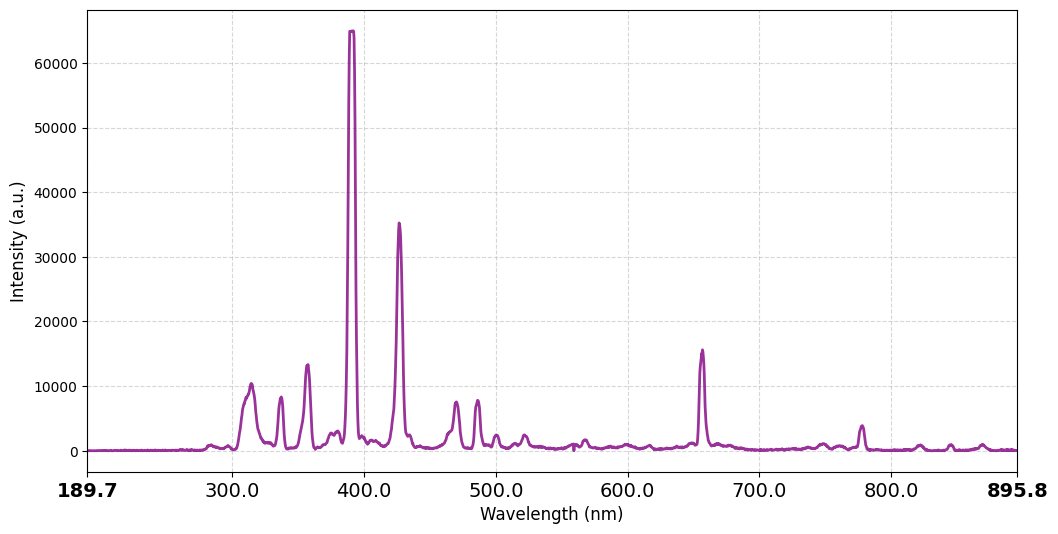

In [63]:
index_instance = result[result["ANOMALY?"]==1].index[0]+1

fig, ax1 = plt.subplots(figsize=(12, 6))

wavelengths = result.columns[1:2049].astype(float)
intensities = result.iloc[index_instance, 1:2049]

line, = ax1.plot(wavelengths, intensities, color="purple", linewidth=2, alpha=0.8)

ax1.set_xlabel('Wavelength (nm)', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Intensity (a.u.)', fontsize=FONTSIZE_SEC)

ax1.grid(True, linestyle="--", alpha=0.5)

min_wave = wavelengths.min()
max_wave = wavelengths.max()

margin = (max_wave - min_wave) * 0
ax1.set_xlim(min_wave - margin, max_wave + margin)

current_ticks = ax1.get_xticks()
filtered_ticks = [t for t in current_ticks if t > min_wave + 30 and t < max_wave - 30]
ax1.set_xticks([min_wave] + filtered_ticks + [max_wave])

ax1.tick_params(axis='x', labelsize=14)

labels = ax1.get_xticklabels()
labels[0].set_fontweight('bold')
labels[0].set_color('black')
labels[-1].set_fontweight('bold')
labels[-1].set_color('black')

plt.savefig("img_spectra/example_spectral_data.pdf", format="pdf", bbox_inches="tight")

In [64]:
start_idx = result[result["ANOMALY?"]==1].index[0] - 5
end_idx = result[result["ANOMALY?"]==1].index[0] + 5

min_y = result.iloc[start_idx:end_idx, 1:2049].min().min()
max_y = result.iloc[start_idx:end_idx, 1:2049].max().max()
ax1.set_ylim(min_y, max_y * 1.1)

def update_plot(frame_index):
    new_intensities = result.iloc[frame_index, 1:2049]
    line.set_ydata(new_intensities)
    
    if result.iloc[frame_index, -1] == 1:
        line.set_color("red")
    else:
        line.set_color("purple")
        
    return line,

frames_to_render = range(start_idx, end_idx)

for frame in frames_to_render:
    update_plot(frame)
    #fig.savefig(rf"img_spectra\frame_{frame}.png", format="png", bbox_inches="tight")

ani = animation.FuncAnimation(fig, update_plot, frames=frames_to_render, blit=True)

#ani.save(r"img_spectra\spectral_animation.gif", writer="pillow", fps=5)
plt.close(fig)